# Notebook 1 — Promotion Accounting
### Incremental sales, cost structure, and ROI by factor

**The question:** for every promotion the retailer ran, how much extra volume did it create, what did it cost, and did it pay for itself?

**The whole method in one line:**

> incremental sales = actual sales − what would have sold anyway (baseline)

Everything else is decomposition: *which* factors move that number, and *which* factors move the cost.

| Section | Output |
|---|---|
| 1 | Weekly fact table — sales, promo mechanics, funding split |
| 2 | Baseline model **and its validation** |
| 3 | Incremental sales |
| 4 | Cost structure — retailer-funded vs vendor-funded |
| 5 | **ROI by factor** — display position, mailer position, brand, discount depth, category |
| 6 | Cannibalization, including brand switching |
| 7 | Full scorecard and ranking |

Notebook 2 then tests how much of this is genuinely *caused* by the promotion.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt

BASE = "."
ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.edgecolor":"#c3c2b7",
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":10,"axes.titlesize":11,
    "axes.titleweight":"bold","xtick.color":MUTED,"ytick.color":MUTED,"legend.frameon":False})
pd.set_option("display.width", 220); pd.set_option("display.max_rows", 80)

# ten heavily promoted, high-turnover categories: wide enough to compare factors,
# small enough that every cell of every breakdown still has data behind it
CATEGORIES = ["SOFT DRINKS","CHEESE","BAG SNACKS","FROZEN PIZZA","CRACKERS/MISC BKD FD",
              "COLD CEREAL","FRZN MEAT/MEAT DINNERS","YOGURT","ICE CREAM/MILK/SHERBTS","COOKIES/CONES"]
GROSS_MARGIN = 0.25    # not present in the data; stated as an assumption, stress-tested in section 7

# dunnhumby codebook for the two in-store mechanics
DISPLAY_NAME = {"0":"not on display","1":"store front","2":"store rear","3":"front end cap",
                "4":"mid-aisle end cap","5":"rear end cap","6":"side-aisle end cap",
                "7":"front shelf","8":"mid-shelf","9":"rear shelf","A":"promo shelf"}
MAILER_NAME  = {"0":"not in mailer","A":"interior page feature","C":"interior page line item",
                "D":"front page feature","F":"back page feature","H":"wrap front feature",
                "J":"wrap interior coupon","L":"wrap back feature","P":"interior page coupon",
                "X":"free on interior page","Z":"free on front/back/wrap"}
print(f"{len(CATEGORIES)} categories in scope")

10 categories in scope


## 1. Weekly fact table

Three files are joined: `transaction_data` (what sold), `product` (what it is), `causal_data` (what promotion it was under, and in which exact position).

Two decisions that shape every number downstream:

**Split the discount by who funds it.** `RETAIL_DISC` and `COUPON_MATCH_DISC` come out of the retailer's margin. `COUPON_DISC` is a manufacturer coupon — the retailer is reimbursed. Only the first group belongs in retailer ROI.

**Balance the panel.** Weeks with no sale must be filled with zero. Keeping only weeks that had a sale would inflate the baseline and hide every promotion that failed to move anything.

We also keep the **raw display and mailer codes**, not just an on/off flag — position within the store and position within the mailer are two of the strongest factors in this analysis.

In [2]:
product = pd.read_csv(f"{BASE}/product.csv")
pm = product[["PRODUCT_ID","COMMODITY_DESC","SUB_COMMODITY_DESC","DEPARTMENT",
              "BRAND","MANUFACTURER"]].drop_duplicates("PRODUCT_ID")
sel_pids = set(pm.loc[pm.COMMODITY_DESC.isin(CATEGORIES), "PRODUCT_ID"])

tx = pd.read_csv(f"{BASE}/transaction_data.csv",
    dtype={"household_key":"int32","BASKET_ID":"int64","DAY":"int16","PRODUCT_ID":"int32",
           "QUANTITY":"int32","SALES_VALUE":"float32","STORE_ID":"int32","RETAIL_DISC":"float32",
           "TRANS_TIME":"int32","WEEK_NO":"int16","COUPON_DISC":"float32","COUPON_MATCH_DISC":"float32"})

# causal_data is 36.8M rows; read in chunks and keep only our categories
parts = []
for ch in pd.read_csv(f"{BASE}/causal_data.csv", chunksize=6_000_000,
                      dtype={"PRODUCT_ID":"int32","STORE_ID":"int32","WEEK_NO":"int16",
                             "display":"str","mailer":"str"}):
    parts.append(ch[ch.PRODUCT_ID.isin(sel_pids)])
cz = pd.concat(parts, ignore_index=True); del parts

# a product-store-week can carry several placements; keep the most prominent of each kind
DRANK = {"0":0,"7":1,"8":1,"9":1,"A":2,"1":3,"2":3,"3":3,"4":3,"5":3,"6":3}
MRANK = {"0":0,"C":1,"A":2,"P":2,"J":2,"D":3,"F":3,"H":3,"L":3,"X":3,"Z":3}
cz["d_rank"] = cz.display.map(DRANK).fillna(0).astype(np.int8)
cz["m_rank"] = cz.mailer.map(MRANK).fillna(0).astype(np.int8)
cz = (cz.sort_values(["d_rank","m_rank"])
        .groupby(["PRODUCT_ID","STORE_ID","WEEK_NO"], as_index=False)
        .agg(display=("display","last"), mailer=("mailer","last"),
             d_rank=("d_rank","max"), m_rank=("m_rank","max")))

STORES = set(cz.STORE_ID.unique()); W0, W1 = int(cz.WEEK_NO.min()), int(cz.WEEK_NO.max())
print(f"promotion log      : {len(cz):,} product-store-weeks")
print(f"coverage           : {len(STORES)} of {tx.STORE_ID.nunique()} stores, weeks {W0}-{W1}")
print(f"                     those stores carry "
      f"{100*tx[tx.STORE_ID.isin(STORES)].SALES_VALUE.sum()/tx.SALES_VALUE.sum():.1f}% of chain revenue")
print(f"key fact           : causal_data contains no row with both codes off, so it is an AD LOG,")
print(f"                     not a panel -- a missing row means 'no promotion'")

promotion log      : 12,208,414 product-store-weeks
coverage           : 115 of 582 stores, weeks 9-101
                     those stores carry 98.5% of chain revenue
key fact           : causal_data contains no row with both codes off, so it is an AD LOG,
                     not a panel -- a missing row means 'no promotion'


In [3]:
t = tx[tx.PRODUCT_ID.isin(sel_pids) & tx.STORE_ID.isin(STORES) & tx.WEEK_NO.between(W0, W1)].copy()
t = t[(t.QUANTITY > 0) & (t.QUANTITY <= 50) & (t.SALES_VALUE > 0)]   # drop voids and weight-priced lines
t["retailer_disc"] = t.RETAIL_DISC.abs() + t.COUPON_MATCH_DISC.abs()  # retailer pays
t["vendor_disc"]   = t.COUPON_DISC.abs()                              # manufacturer pays

fact = t.groupby(["PRODUCT_ID","STORE_ID","WEEK_NO"], as_index=False).agg(
    units=("QUANTITY","sum"), revenue=("SALES_VALUE","sum"),
    retailer_disc=("retailer_disc","sum"), vendor_disc=("vendor_disc","sum"),
    buyers=("household_key","nunique"))

hist = fact.groupby(["PRODUCT_ID","STORE_ID"]).WEEK_NO.nunique()
keep = hist[hist >= 20].index                                          # need a history to have a baseline
df = (pd.DataFrame(list(keep), columns=["PRODUCT_ID","STORE_ID"])
        .merge(pd.DataFrame({"WEEK_NO": np.arange(W0, W1+1, dtype="int16")}), how="cross")
        .merge(fact, on=["PRODUCT_ID","STORE_ID","WEEK_NO"], how="left"))
for c in ["units","revenue","retailer_disc","vendor_disc","buyers"]: df[c] = df[c].fillna(0.0)
df = df.merge(cz, on=["PRODUCT_ID","STORE_ID","WEEK_NO"], how="left")
df["display"] = df.display.fillna("0"); df["mailer"] = df.mailer.fillna("0")
df[["d_rank","m_rank"]] = df[["d_rank","m_rank"]].fillna(0).astype(np.int8)
df["on_display"] = (df.d_rank > 0).astype(np.int8)
df["on_mailer"]  = (df.m_rank > 0).astype(np.int8)
df["promo"]      = ((df.on_display + df.on_mailer) > 0).astype(np.int8)
df["mech"] = np.where(df.on_display & df.on_mailer, "display + mailer",
             np.where(df.on_display == 1, "display only",
             np.where(df.on_mailer == 1, "mailer only", "none")))
df = df.merge(pm, on="PRODUCT_ID", how="left")
df["key"] = df.PRODUCT_ID.astype(str) + "_" + df.STORE_ID.astype(str)

print(f"panel        : {len(df):,} rows = {df.key.nunique():,} product-stores x {W1-W0+1} weeks")
print(f"on promotion : {df.promo.mean():.1%} of cells | no sale in the week: {(df.units==0).mean():.1%}")
print(f"volume       : {df.units.sum():,.0f} units, ${df.revenue.sum():,.0f} revenue")
print(f"discounts    : retailer-funded ${df.retailer_disc.sum():,.0f} | "
      f"vendor-funded ${df.vendor_disc.sum():,.0f}")
print("\npromotion mix:")
print((df[df.promo==1].mech.value_counts(normalize=True)*100).round(1).to_string())

panel        : 181,536 rows = 1,952 product-stores x 93 weeks
on promotion : 31.0% of cells | no sale in the week: 68.9%
volume       : 110,364 units, $192,344 revenue
discounts    : retailer-funded $58,087 | vendor-funded $1,574

promotion mix:
mech
mailer only         35.3
display + mailer    34.5
display only        30.2


## 2. Baseline — what would have sold without the promotion

$$\text{baseline}_{p,s,w} = \underbrace{\overline{\text{units}}_{p,s}}_{\text{how this item normally sells here}} \times \underbrace{\text{seasonal index}_w}_{\text{how the whole market moves that week}}$$

Both components are estimated **only from weeks with no promotion**, so the promotion never leaks into its own counterfactual.

A baseline is only worth as much as its validation, so we score it on the non-promoted weeks it never saw as a target.

price available for 100.0% of panel cells after imputation
BASELINE VALIDATION on non-promoted weeks
  predicted 61,841 units vs actual 61,812
  bias -0.0%   |   mean absolute error 0.65 units per cell
  the seasonal index alone spans 0.39x to 1.29x -- ignoring it would misprice every promotion


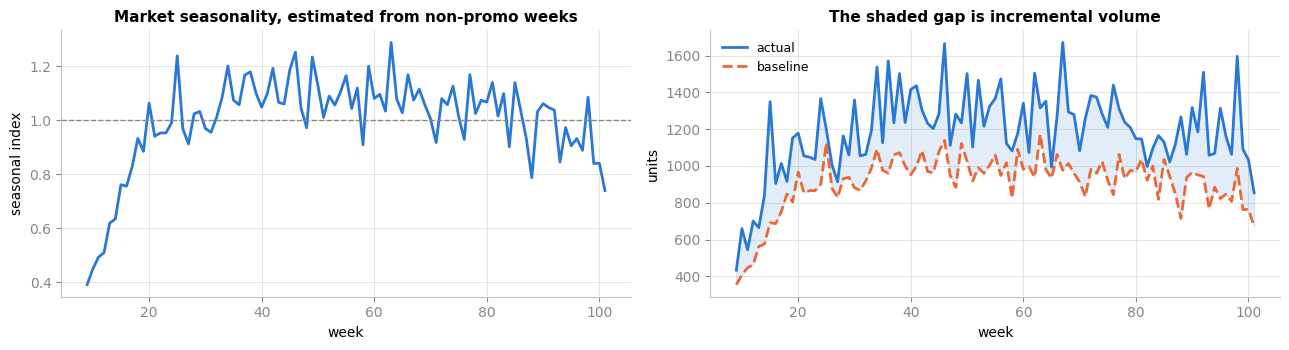

In [4]:
nz = df[df.promo == 0]
season = (nz.groupby("WEEK_NO").units.mean() / nz.units.mean()).rename("season_idx")
level  = nz.groupby("key").units.mean().rename("base_level")
df = df.merge(season, on="WEEK_NO", how="left").merge(level, on="key", how="left")
df["base_level"] = df.base_level.fillna(0)
df["baseline"]   = df.base_level * df.season_idx

# Price for EVERY cell, not only cells that sold. A promoted week that sold nothing still had a
# shelf price, and leaving it out would silently drop the failures from every price breakdown.
df["price_obs"] = np.where(df.units > 0, df.revenue/df.units.replace(0, np.nan), np.nan)
pw = df.groupby(["PRODUCT_ID","WEEK_NO"]).price_obs.median().rename("_pw")
pp = df.groupby("PRODUCT_ID").price_obs.median().rename("_pp")
df = df.merge(pw, on=["PRODUCT_ID","WEEK_NO"], how="left").merge(pp, on="PRODUCT_ID", how="left")
df["price_est"] = df.price_obs.fillna(df["_pw"]).fillna(df["_pp"])
ref_price = (df[df.promo == 0].groupby("key").price_est.median().rename("ref_price"))
df = df.merge(ref_price, on="key", how="left")
df["cut_est"] = (1 - df.price_est/df.ref_price).clip(-1, 0.95)
df = df.drop(columns=["_pw","_pp"])
print(f"price available for {100*df.price_est.notna().mean():.1f}% of panel cells after imputation")

chk = df[df.promo == 0]
print("BASELINE VALIDATION on non-promoted weeks")
print(f"  predicted {chk.baseline.sum():,.0f} units vs actual {chk.units.sum():,.0f}")
print(f"  bias {100*(chk.units.sum()-chk.baseline.sum())/chk.baseline.sum():+.1f}%"
      f"   |   mean absolute error {(chk.units-chk.baseline).abs().mean():.2f} units per cell")
print("  the seasonal index alone spans "
      f"{season.min():.2f}x to {season.max():.2f}x -- ignoring it would misprice every promotion")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(season.index, season.values, color=ACCENT, lw=2)
axes[0].axhline(1, color=MUTED, lw=1, ls="--")
axes[0].set_xlabel("week"); axes[0].set_ylabel("seasonal index")
axes[0].set_title("Market seasonality, estimated from non-promo weeks")
wk = df.groupby("WEEK_NO").agg(actual=("units","sum"), base=("baseline","sum"))
axes[1].plot(wk.index, wk.actual, color=ACCENT, lw=2, label="actual")
axes[1].plot(wk.index, wk.base, color=ACCENT2, lw=2, ls="--", label="baseline")
axes[1].fill_between(wk.index, wk.base, wk.actual, where=wk.actual >= wk.base, color=ACCENT, alpha=0.13)
axes[1].set_xlabel("week"); axes[1].set_ylabel("units")
axes[1].set_title("The shaded gap is incremental volume"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 3. Incremental sales

In [5]:
p = df[df.promo == 1].copy()
p["incr_units"] = p.units - p.baseline
gross_units = p.incr_units.sum()

print(f"promoted product-weeks : {len(p):,}")
print(f"actual                 : {p.units.sum():,.0f} units")
print(f"baseline               : {p.baseline.sum():,.0f} units")
print(f"incremental            : {gross_units:+,.0f} units ({100*gross_units/p.baseline.sum():+.1f}%)")
print(f"\n{100*p.baseline.sum()/p.units.sum():.0f}% of promoted volume would have sold anyway.")
print("That share is what makes discounting expensive: the markdown is paid on all of it.")

by_c = (p.groupby("COMMODITY_DESC")
         .apply(lambda g: pd.Series({"promo_weeks": len(g), "actual": g.units.sum(),
                                     "baseline": g.baseline.sum(), "incremental": g.incr_units.sum(),
                                     "lift_%": 100*g.incr_units.sum()/max(g.baseline.sum(), 1e-9)}),
                include_groups=False)
         .sort_values("incremental", ascending=False))
print("\nby category:"); print(by_c.round(1).to_string())

promoted product-weeks : 56,260
actual                 : 48,552 units
baseline               : 22,591 units
incremental            : +25,961 units (+114.9%)

47% of promoted volume would have sold anyway.
That share is what makes discounting expensive: the markdown is paid on all of it.

by category:
                        promo_weeks   actual  baseline  incremental  lift_%
COMMODITY_DESC                                                             
SOFT DRINKS                 21468.0  26047.0    9401.1      16645.9   177.1
CHEESE                      14652.0  10913.0    5941.4       4971.6    83.7
BAG SNACKS                   7922.0   4009.0    1674.6       2334.4   139.4
CRACKERS/MISC BKD FD         3326.0   1716.0    1067.3        648.7    60.8
YOGURT                       3557.0   2819.0    2323.7        495.3    21.3
FROZEN PIZZA                 1795.0   1017.0     766.0        251.0    32.8
FRZN MEAT/MEAT DINNERS       1465.0   1014.0     785.8        228.2    29.0
COOKIES/CONES 

## 4. Cost structure — who actually pays

The cost of a promotion is **not** the whole discount. Loyalty-card markdowns run in ordinary weeks too. The promotion's cost is the *extra* discount versus how that same item is normally priced in that same store:

$$\text{cost} = \left(\frac{\text{discount}}{\text{unit}}\bigg|_{\text{promo}} - \frac{\text{discount}}{\text{unit}}\bigg|_{\text{normal}}\right)\times\text{units sold}$$

Two checks worth watching: the extra discount per unit should mirror the price drop per unit almost exactly, and the vendor-funded share should be reported separately so it never flatters the retailer's ROI.

In [6]:
sold_np = df[(df.promo == 0) & (df.units > 0)]
base_pu = (sold_np.assign(d=lambda x: x.retailer_disc/x.units, pr=lambda x: x.revenue/x.units)
                  .groupby("key")[["d","pr"]].mean()
                  .rename(columns={"d":"base_disc_pu","pr":"base_price"}))
p = p.merge(base_pu, on="key", how="left")
ps = p[(p.units > 0) & p.base_disc_pu.notna()].copy()          # price exists only where something sold
ps["price"]      = ps.revenue/ps.units
ps["extra_disc"] = (ps.retailer_disc/ps.units - ps.base_disc_pu)*ps.units
ps["cut"]        = 1 - ps.price/ps.base_price

print("PER-UNIT ECONOMICS on promoted weeks (each item vs its own normal weeks)")
print(f"  retailer discount : ${(ps.retailer_disc/ps.units).mean():.3f} on promo vs "
      f"${ps.base_disc_pu.mean():.3f} normally  (extra ${(ps.retailer_disc/ps.units - ps.base_disc_pu).mean():+.3f})")
print(f"  net price         : ${ps.price.mean():.3f} on promo vs ${ps.base_price.mean():.3f} normally  "
      f"({ps.price.mean()-ps.base_price.mean():+.3f})")
print("  the two move together to the cent, so the cost accounting is internally consistent")
print(f"\n  total extra discount, retailer-funded : ${ps.extra_disc.sum():,.0f}")
print(f"  total vendor-funded coupons          : ${p.vendor_disc.sum():,.0f} "
      f"({100*p.vendor_disc.sum()/(ps.extra_disc.sum()+p.vendor_disc.sum()):.1f}% of all promotional funding)")

print("\nfunding and depth by mechanism:")
mm = (ps.groupby("mech").apply(lambda g: pd.Series({
        "promo_weeks": len(g),
        "median_depth_%": 100*g.cut.median(),
        "extra_disc_$": g.extra_disc.sum(),
        "disc_per_unit_$": g.extra_disc.sum()/max(g.units.sum(), 1)}), include_groups=False)
      .sort_values("disc_per_unit_$"))
print(mm.round(2).to_string())
print("\n  mailer campaigns come with markedly deeper price cuts than display-only ones.")
print("  That is the single biggest driver of the ROI gap in section 5.")

PER-UNIT ECONOMICS on promoted weeks (each item vs its own normal weeks)
  retailer discount : $0.792 on promo vs $0.336 normally  (extra $+0.455)
  net price         : $1.886 on promo vs $2.338 normally  (-0.452)
  the two move together to the cent, so the cost accounting is internally consistent

  total extra discount, retailer-funded : $26,821
  total vendor-funded coupons          : $1,404 (5.0% of all promotional funding)

funding and depth by mechanism:
                  promo_weeks  median_depth_%  extra_disc_$  disc_per_unit_$
mech                                                                        
display only           5457.0            0.55        857.16             0.09
mailer only            7078.0           18.70       7526.26             0.50
display + mailer       9113.0           27.04      18437.96             0.79

  mailer campaigns come with markedly deeper price cuts than display-only ones.
  That is the single biggest driver of the ROI gap in section 5.


## 5. ROI by factor

This is the heart of the notebook. The same ROI formula is applied inside every level of every factor:

$$\text{ROI} = \frac{\text{net incremental units}\times\text{price}\times\text{margin} - \text{extra discount}}{\text{extra discount}}$$

Factors examined: **mechanism**, **display position**, **mailer position**, **brand**, **discount depth**, and **category**. `breakeven_margin` is the gross margin the promotion would need to wash its face — it makes each row readable without trusting the 25% assumption.

In [7]:
RETENTION = 1.0    # placeholder; section 6 measures cannibalization and resets this

def roi_table(frame_all, frame_sold, by, min_weeks=150, retention=None):
    # frame_all carries volume (incl. promoted weeks that sold nothing); frame_sold carries price/discount
    r = RETENTION if retention is None else retention
    rows = []
    for lvl in frame_all[by].dropna().unique():
        ga, gs = frame_all[frame_all[by] == lvl], frame_sold[frame_sold[by] == lvl]
        if len(ga) < min_weeks or len(gs) < 50 or gs.units.sum() == 0: continue
        inc  = ga.incr_units.sum()*r
        rev  = inc*(gs.revenue.sum()/gs.units.sum())
        cost = gs.extra_disc.sum()
        # a non-positive extra discount means the item was NOT cheaper than usual during the
        # promotion; there is no markdown to earn back, so ROI is undefined rather than negative
        rows.append({by: lvl, "promo_weeks": len(ga),
                     "lift_%": round(100*ga.incr_units.sum()/max(ga.baseline.sum(), 1e-9), 1),
                     "incr_units": round(inc), "incr_revenue_$": round(rev),
                     "extra_disc_$": round(cost),
                     "ROI": round((rev*GROSS_MARGIN-cost)/cost, 2) if cost > 0 else np.nan,
                     "breakeven_margin": round(cost/rev, 2) if (rev > 0 and cost > 0) else np.nan,
                     "note": "" if cost > 0 else "no extra markdown - free volume"})
    return pd.DataFrame(rows).sort_values("ROI", ascending=False, na_position="first")

print("="*78); print("FACTOR 1 -- mechanism"); print("="*78)
print(roi_table(p, ps, "mech", min_weeks=300).to_string(index=False))

print("\n" + "="*78); print("FACTOR 2 -- display position (display-only weeks, so the mailer does not confound)")
print("="*78)
pd_only, ps_only = p[p.on_mailer == 0], ps[ps.on_mailer == 0]
t2 = roi_table(pd_only, ps_only, "display", min_weeks=120)
t2["position"] = t2.display.map(DISPLAY_NAME)
print(t2[["display","position","promo_weeks","lift_%","incr_units","extra_disc_$","ROI","breakeven_margin","note"]]
      .to_string(index=False))

print("\n" + "="*78); print("FACTOR 3 -- mailer position (mailer-only weeks)"); print("="*78)
pm_only, psm_only = p[p.on_display == 0], ps[ps.on_display == 0]
t3 = roi_table(pm_only, psm_only, "mailer", min_weeks=120)
t3["position"] = t3.mailer.map(MAILER_NAME)
print(t3[["mailer","position","promo_weeks","lift_%","incr_units","extra_disc_$","ROI","breakeven_margin","note"]]
      .to_string(index=False))

FACTOR 1 -- mechanism
            mech  promo_weeks  lift_%  incr_units  incr_revenue_$  extra_disc_$   ROI  breakeven_margin note
    display only        16970    51.5        3305            6491           857  0.89              0.13     
display + mailer        19430   230.5       16476           31149         18438 -0.58              0.59     
     mailer only        19860    68.5        6180            9869          7526 -0.67              0.76     

FACTOR 2 -- display position (display-only weeks, so the mailer does not confound)
display           position  promo_weeks  lift_%  incr_units  extra_disc_$   ROI  breakeven_margin note
      9         rear shelf         4892    59.6        1028           112  3.75              0.05     
      5       rear end cap         1697    49.9         341            57  1.52              0.10     
      2         store rear         1718    48.4         331            72  1.13              0.12     
      6 side-aisle end cap         1491    50.

mailer                position  promo_weeks  lift_%  incr_units  extra_disc_$   ROI  breakeven_margin                            note
     X   free on interior page          328     2.1           3           -46   NaN               NaN no extra markdown - free volume
     J    wrap interior coupon          287   113.2         148           108 -0.56              0.57                                
     A   interior page feature         9935    40.8        1991          1935 -0.64              0.69                                
     D      front page feature         7624   118.7        3726          5196 -0.68              0.79                                
     H      wrap front feature         1243    30.7         174           217 -0.72              0.89                                
     C interior page line item          229    21.0          17            29 -0.74              0.97                                


In [8]:
print("="*78); print("FACTOR 4 -- brand tier"); print("="*78)
print(roi_table(p, ps, "BRAND", min_weeks=300).to_string(index=False))

print("\n" + "="*78); print("FACTOR 5 -- discount depth"); print("="*78)
DEPTH_BINS = [-9, 0.02, 0.10, 0.20, 0.30, 0.45, 9]
DEPTH_LAB  = ["~0% (ad only)","2-10%","10-20%","20-30%","30-45%","45%+"]
# depth is assigned from the imputed price, so promoted weeks that sold nothing are included too
p["depth"]  = pd.cut(p.cut_est,  DEPTH_BINS, labels=DEPTH_LAB)
ps["depth"] = pd.cut(ps.cut_est, DEPTH_BINS, labels=DEPTH_LAB)
t5 = roi_table(p[p.depth.notna()], ps[ps.depth.notna()], "depth", min_weeks=150)
print(t5.to_string(index=False))
print(f"\n  reconciliation: incremental units across depth bands = {t5.incr_units.sum():,.0f}"
      f"  (total gross incremental {gross_units:,.0f})")
print("  ad-only promotions -- featured without cutting price -- are the cheapest volume available.")

print("\n" + "="*78); print("FACTOR 6 -- category"); print("="*78)
print(roi_table(p, ps, "COMMODITY_DESC", min_weeks=300).to_string(index=False))

FACTOR 4 -- brand tier


   BRAND  promo_weeks  lift_%  incr_units  incr_revenue_$  extra_disc_$   ROI  breakeven_margin note
 Private        20023    53.6        4901            6261          1706 -0.08              0.27     
National        36237   156.6       21060           42769         25115 -0.57              0.59     

FACTOR 5 -- discount depth
        depth  promo_weeks  lift_%  incr_units  incr_revenue_$  extra_disc_$   ROI  breakeven_margin                            note
~0% (ad only)        24002    19.0        1843            3385          -446   NaN               NaN no extra markdown - free volume
        2-10%         4115    74.6        1243            2198           241  1.28              0.11                                
       10-20%         7768    98.6        3172            5196          1582 -0.18              0.30                                
       20-30%         9916   143.5        5679            9403          5223 -0.55              0.56                                
    

        COMMODITY_DESC  promo_weeks  lift_%  incr_units  incr_revenue_$  extra_disc_$   ROI  breakeven_margin note
            BAG SNACKS         7922   139.4        2334            4629          1245 -0.07              0.27     
          FROZEN PIZZA         1795    32.8         251             474           149 -0.20              0.31     
                CHEESE        14652    83.7        4972            7321          2528 -0.28              0.35     
  CRACKERS/MISC BKD FD         3326    60.8         649             999           395 -0.37              0.40     
         COOKIES/CONES          955    71.7         180             401           205 -0.51              0.51     
           SOFT DRINKS        21468   177.1       16646           34814         21486 -0.59              0.62     
                YOGURT         3557    21.3         495             236           163 -0.64              0.69     
FRZN MEAT/MEAT DINNERS         1465    29.0         228             280         

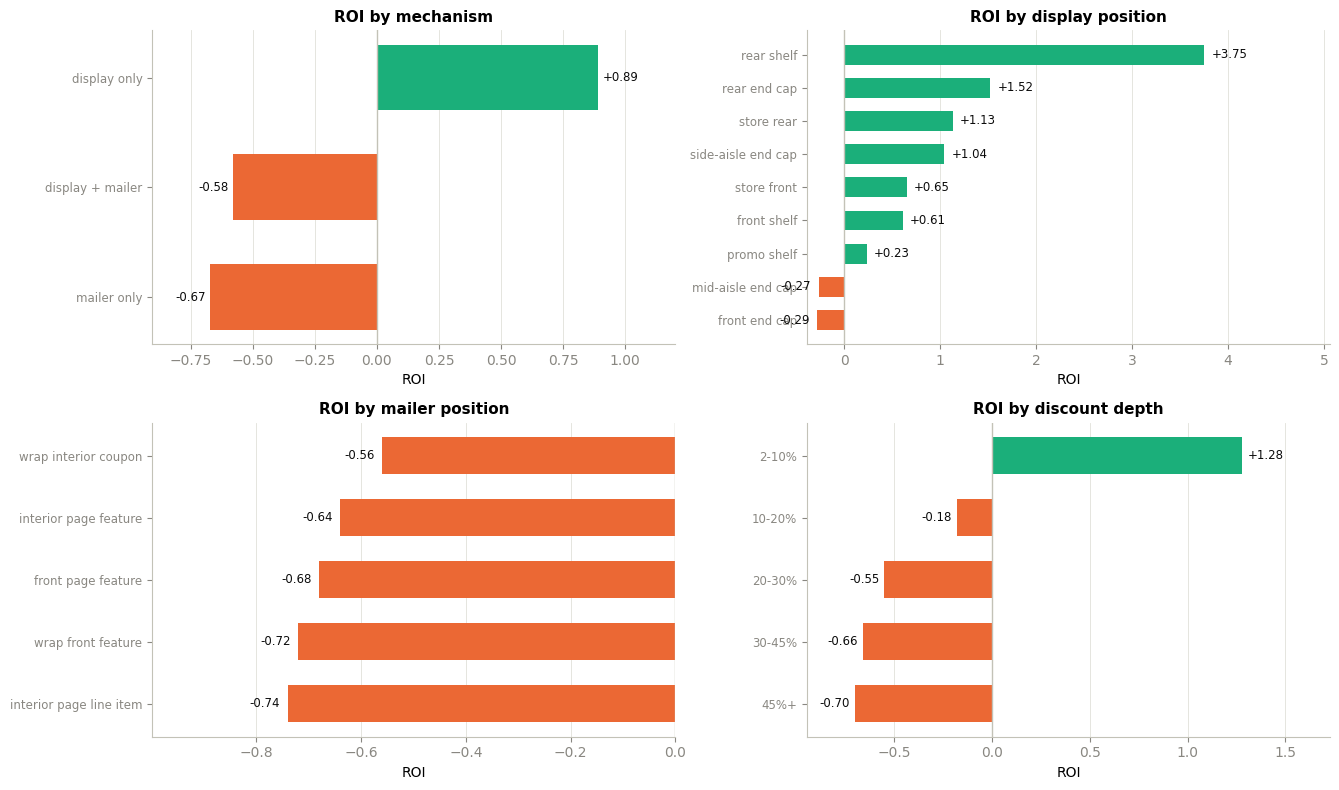

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))

def hbar(ax, frame, labcol, valcol, title, xlabel, fmt="{:+.2f}"):
    o = frame.dropna(subset=[valcol]).sort_values(valcol)
    ys = np.arange(len(o))
    ax.barh(ys, o[valcol], color=[ACCENT3 if v > 0 else ACCENT2 for v in o[valcol]], height=0.6)
    ax.axvline(0, color="#c3c2b7", lw=1)
    span = max(abs(o[valcol].max()), abs(o[valcol].min())) or 1
    for i, v in enumerate(o[valcol]):
        ax.text(v + (0.02*span if v > 0 else -0.02*span), i, fmt.format(v), va="center",
                ha="left" if v > 0 else "right", fontsize=8.5, color=INK)
    ax.set_yticks(ys); ax.set_yticklabels([str(x)[:26] for x in o[labcol]], fontsize=8.5)
    ax.set_xlabel(xlabel); ax.set_title(title); ax.grid(axis="y", visible=False)
    ax.set_xlim(min(0, o[valcol].min())*1.35, max(0, o[valcol].max())*1.35)

hbar(axes[0,0], roi_table(p, ps, "mech", min_weeks=300), "mech", "ROI", "ROI by mechanism", "ROI")
hbar(axes[0,1], t2.assign(lab=t2.position), "lab", "ROI", "ROI by display position", "ROI")
hbar(axes[1,0], t3.assign(lab=t3.position), "lab", "ROI", "ROI by mailer position", "ROI")
hbar(axes[1,1], t5, "depth", "ROI", "ROI by discount depth", "ROI")
plt.tight_layout(); plt.show()

## 6. Cannibalization

Volume stolen from rivals inside the same sub-category is not new demand.

The counterfactual has to be built carefully. If a rival's baseline is taken from *its own* non-promoted weeks, those weeks are themselves contaminated — its neighbours were on promotion in most of them. So the rival baseline is rebuilt from **clean weeks only**: weeks in which nothing at all in that sub-category was promoted.

In [10]:
scw = (df.groupby(["SUB_COMMODITY_DESC","STORE_ID","WEEK_NO"], as_index=False).promo.max()
         .rename(columns={"promo":"sc_promo"}))
d2 = df.merge(scw, on=["SUB_COMMODITY_DESC","STORE_ID","WEEK_NO"], how="left")
clean = d2[d2.sc_promo == 0]
clean_lvl = clean.groupby("key").units.mean().rename("clean_level")
d2 = d2.merge(clean_lvl, on="key", how="left")
d2["clean_base"] = d2.clean_level * d2.season_idx
rivals = d2[(d2.promo == 0) & (d2.sc_promo == 1) & d2.clean_level.notna()]

cann = rivals.units.sum() - rivals.clean_base.sum()
net_units = gross_units + cann
RETENTION = net_units/gross_units
print(f"clean weeks available (nothing in the sub-category promoted): {100*len(clean)/len(d2):.0f}% of cells")
print(f"rivals during promo weeks : actual {rivals.units.sum():,.0f} vs clean baseline {rivals.clean_base.sum():,.0f}")
print(f"cannibalized              : {cann:+,.0f} units ({100*cann/max(rivals.clean_base.sum(),1e-9):+.1f}%)")
print(f"\ngross incremental {gross_units:+,.0f}  ->  net incremental {net_units:+,.0f}"
      f"   (retention {RETENTION:.2f})")

print("\ncannibalization by rival brand tier -- does promoting one brand hurt the other?")
for bd, g in rivals.groupby("BRAND"):
    delta = g.units.sum() - g.clean_base.sum()
    print(f"  rival is {bd:9}: {delta:+8,.0f} units "
          f"({100*delta/max(g.clean_base.sum(),1e-9):+5.1f}%)  n={len(g):,}")
print("\ncaveat: only rivals inside these ten categories and inside the panel are counted,")
print("        so this is a lower bound on true switching")

clean weeks available (nothing in the sub-category promoted): 53% of cells
rivals during promo weeks : actual 12,681 vs clean baseline 13,398
cannibalized              : -717 units (-5.4%)

gross incremental +25,961  ->  net incremental +25,244   (retention 0.97)

cannibalization by rival brand tier -- does promoting one brand hurt the other?
  rival is National :      +12 units ( +0.2%)  n=17,928
  rival is Private  :     -729 units (-12.5%)  n=10,870

caveat: only rivals inside these ten categories and inside the panel are counted,
        so this is a lower bound on true switching


## 7. Final scorecard

SCORECARD at 25% gross margin, net of cannibalization (retention 0.97)
            mech  promo_weeks  lift_%  incr_units  incr_revenue_$  extra_disc_$   ROI  breakeven_margin note
    display only        16970    51.5        3214            6312           857  0.84              0.14     
display + mailer        19430   230.5       16021           30289         18438 -0.59              0.61     
     mailer only        19860    68.5        6009            9596          7526 -0.68              0.78     

reconciliation: incremental units across mechanisms = 25,244  (net incremental computed in section 6: 25,244)

sensitivity of the verdict to the margin assumption:
gross_margin  display only  display + mailer  mailer only
         15%          0.10             -0.75        -0.81
         20%          0.47             -0.67        -0.74
         25%          0.84             -0.59        -0.68
         30%          1.21             -0.51        -0.62
         35%          1.58            

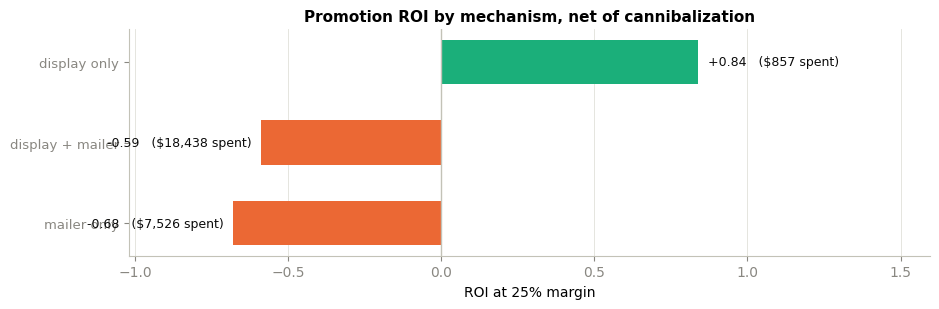

In [ ]:
score = roi_table(p, ps, "mech", min_weeks=300, retention=RETENTION)
print(f"SCORECARD at {GROSS_MARGIN:.0%} gross margin, net of cannibalization (retention {RETENTION:.2f})")
print(score.to_string(index=False))
print(f"\nreconciliation: incremental units across mechanisms = {score.incr_units.sum():,.0f}"
      f"  (net incremental computed in section 6: {net_units:,.0f})")

print("\nsensitivity of the verdict to the margin assumption:")
sens = []
for mgn in [0.15, 0.20, 0.25, 0.30, 0.35]:
    row = {"gross_margin": f"{mgn:.0%}"}
    for _, r in score.iterrows():
        row[r.mech] = round((r["incr_revenue_$"]*mgn - r["extra_disc_$"])/r["extra_disc_$"], 2)
    sens.append(row)
print(pd.DataFrame(sens).to_string(index=False))
ُ
fig, ax = plt.subplots(figsize=(9.5, 3.2))
o = score.sort_values("ROI")
ys = np.arange(len(o))
ax.barh(ys, o.ROI, color=[ACCENT3 if v > 0 else ACCENT2 for v in o.ROI], height=0.55)
ax.axvline(0, color="#c3c2b7", lw=1)
for i, (v, c, r) in enumerate(zip(o.ROI, o["extra_disc_$"], o["incr_revenue_$"])):
    ax.text(v + (0.03 if v > 0 else -0.03), i, f"{v:+.2f}   (${c:,.0f} spent)", va="center",
            ha="left" if v > 0 else "right", fontsize=9, color=INK)
ax.set_yticks(ys); ax.set_yticklabels(o.mech, fontsize=9.5)
ax.set_xlabel(f"ROI at {GROSS_MARGIN:.0%} margin"); ax.set_title("Promotion ROI by mechanism, net of cannibalization")
ax.set_xlim(o.ROI.min()*1.5, max(o.ROI.max()*1.9, 0.5)); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## Summary — what the accounting says

**Volume is real; profit is not automatic.** Promoted weeks sell 115% above baseline, but **47% of promoted volume would have sold anyway** and the markdown is paid on all of it.

**Discount depth is the factor that decides ROI — not the mechanism itself.**

| discount depth | lift | ROI @25% |
|---|---|---|
| ~0% (featured, no price cut) | +19% | free volume — no markdown at all |
| 2–10% | +75% | **+1.28** |
| 10–20% | +99% | −0.18 |
| 20–30% | +144% | −0.55 |
| 30–45% | +341% | −0.66 |
| 45%+ | +421% | −0.70 |

Deeper cuts keep buying more volume all the way up, and keep destroying more margin all the way up. The profitable window closes somewhere around a 10% cut.

**Mechanism matters mainly through the depth it is bundled with.** Display-only weeks carry a median price cut of ~0.6% and return **ROI +0.84**. Mailer weeks carry 19–27% cuts and lose money. Display is not magic — it is just the mechanism that does not require giving away price.

**Position is a free lever with a very wide spread.** Among display-only weeks, ROI ranges from **+3.75 (rear shelf)** to **−0.29 (front end cap)**. Changing where a promoted item sits costs nothing and moves ROI by more than four points.

**Promotions cannibalize private label, not national brands.** Rival national brands are untouched (+0.2%); rival private-label items lose **−12.5%**. Since national brands are the ones usually promoted, the chain is discounting national product and taking the volume out of its own higher-margin private label.

**Private label promotions are nearly breakeven (−0.08) while national ones are not (−0.57)** — consistent with the same story.

### Limitations

- **Gross margin is assumed at 25%** — it is not in the data. The `breakeven_margin` column and the sensitivity table in section 7 exist so no conclusion rests on that number alone.
- **Vendor trade funds are excluded** from retailer ROI by design; they are reported separately in section 4.
- **Cannibalization is a lower bound** — only rivals inside these ten categories are counted.
- **`causal_data` covers 115 stores and weeks 9–101**, so the analysis universe is restricted to that window.
- **Only 2,500 sampled households are observed**, not the full store traffic. Ratios are sound; absolute volumes are sample volumes.
- **Everything here is an accounting difference, not a causal claim.** Notebook 2 tests how much of it survives a real control group.